# Import Dependencies

This notebook implements parameter-efficient fine-tuning techniques for large transformer models
on network traffic data, achieving ~97% parameter reduction while maintaining performance.

## Core Libraries

### Deep Learning Framework
- **PyTorch**: Neural network implementation and training
- **torch.nn.functional**: Low-level operations for custom layers
- **torch.utils.checkpoint**: Gradient checkpointing for memory efficiency
- **DataLoader, Dataset**: Batch processing infrastructure

### Transformer Components
- **transformers**: HuggingFace library for BERT architecture
- **BertModel, BertConfig**: Base transformer implementation
- **BertSelfAttention, BertLayer**: Components for modification
- **get_linear_schedule_with_warmup**: Learning rate scheduling
- **PreTrainedModel**: Base class for model inheritance

### Scientific Computing
- **numpy**: Array operations and numerical computing
- **math**: Mathematical operations (sqrt for attention scaling)
- **sklearn.metrics**: Performance evaluation (MSE, MAE, R²)

### Experiment Management
- **wandb**: Optional experiment tracking
- **logging**: Structured logging for debugging
- **datetime**: Timestamp generation
- **pathlib**: Cross-platform file operations

### Visualization
- **matplotlib, seaborn**: Training curves and analysis plots
- **tqdm**: Progress bars for training loops

### Utilities
- **json**: Configuration persistence
- **dataclasses**: Structured configuration objects
- **warnings**: Suppressed for cleaner output
- **typing**: Type hints for code clarity

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint
from transformers import (
    PreTrainedModel, PretrainedConfig,
    BertConfig, BertModel,
    get_linear_schedule_with_warmup
)
from transformers.models.bert.modeling_bert import BertSelfAttention, BertLayer
import numpy as np
import logging
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Union, Any
from dataclasses import dataclass
import json
import math
from datetime import datetime
import wandb 
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

# LoRALayer - Low-Rank Weight Updates

Implements low-rank matrix decomposition for parameter-efficient updates.
Instead of updating full weight matrix, decomposes into two smaller matrices.

Key components:
- lora_A: First matrix (input_dim × rank)
- lora_B: Second matrix (rank × output_dim)  
- scaling: Alpha/rank ratio for controlling update magnitude
- dropout: Regularization during training

Methods:
- forward(): Computes Wx + (BA)x * scaling
- merge(): Combines LoRA weights into base weights for inference
- unmerge(): Separates LoRA weights from base weights

In [2]:
class LoRALayer(nn.Module):
    """
    Low Rank Adaptation layer for parameter efficient fine tuning.
    Decomposes weight updates into low rank matrices A and B where W' = W + BA * scaling
    """
    def __init__(
        self,
        in_features: int,
        out_features: int,
        rank: int = 16,
        alpha: float = 32,
        dropout: float = 0.1,
        merge_weights: bool = False
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank  # Scaling factor for stable training
        self.merge_weights = merge_weights
        self.merged = False
        
        # Low rank decomposition matrices
        self.lora_A = nn.Parameter(torch.zeros(in_features, rank))
        self.lora_B = nn.Parameter(torch.zeros(rank, out_features))
        self.dropout = nn.Dropout(dropout)
        
        # Initialize A with Kaiming, B with zeros
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)
        
    def forward(self, x: torch.Tensor, base_weight: torch.Tensor) -> torch.Tensor:
        result = F.linear(x, base_weight)
        
        if self.training or not self.merge_weights:
            # Apply LoRA: result = Wx + (BAx) * scaling
            x_dropout = self.dropout(x)
            lora_output = F.linear(F.linear(x_dropout, self.lora_A.T), self.lora_B.T)
            result += lora_output * self.scaling
            
        return result
    
    def merge(self, base_weight: nn.Parameter) -> None:
        """Merge LoRA weights into base weights for inference efficiency """
        if not self.merged:
            base_weight.data += (self.lora_A @ self.lora_B).T * self.scaling
            self.merged = True
    
    def unmerge(self, base_weight: nn.Parameter) -> None:
        """Unmerge LoRA weights from base weights """
        if self.merged:
            base_weight.data -= (self.lora_A @ self.lora_B).T * self.scaling
            self.merged = False

# LoRALinear - Linear Layer with LoRA

Wraps existing linear layer with LoRA components.
Freezes base layer weights and adds trainable LoRA matrices.

Components:
- base_layer: Original frozen linear layer
- lora: LoRALayer instance with low-rank matrices

Forward pass:
- Applies LoRA transformation to input
- Adds base layer bias if present
- Returns combined output

In [3]:
class LoRALinear(nn.Module):
    """
    Wrapper that adds LoRA to an existing Linear layer and freezes the base layer and only trains the low rank adaptation
    """
    def __init__(
        self,
        base_layer: nn.Linear,
        rank: int = 16,
        alpha: float = 32,
        dropout: float = 0.1
    ):
        super().__init__()
        self.base_layer = base_layer
        self.lora = LoRALayer(
            base_layer.in_features,
            base_layer.out_features,
            rank=rank,
            alpha=alpha,
            dropout=dropout
        )
        
        # Freeze base layer parameters
        for param in self.base_layer.parameters():
            param.requires_grad = False
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.lora(x, self.base_layer.weight) + (self.base_layer.bias if self.base_layer.bias is not None else 0)

# AdapterLayer - Bottleneck Module

Adds small trainable module between transformer layers.
Projects to lower dimension, applies activation, projects back.

Architecture:
- down_project: Reduces dimension (hidden → adapter_size)
- activation: Non-linearity (GELU/ReLU/Tanh)
- up_project: Restores dimension (adapter_size → hidden)
- dropout: Applied after each projection

Forward includes residual connection: output = input + adapter(input)

In [4]:
class AdapterLayer(nn.Module):
    """Bottleneck adapter module for task specific fine tuning """
    def __init__(
        self,
        hidden_size: int,
        adapter_size: int = 64,
        dropout: float = 0.1,
        activation: str = 'gelu'
    ):
        super().__init__()
        self.down_project = nn.Linear(hidden_size, adapter_size)
        self.up_project = nn.Linear(adapter_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        
        # Activation function selection
        if activation == 'gelu':
            self.activation = nn.GELU()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Tanh()
        
        # Initializes with small weights for stable training
        nn.init.normal_(self.down_project.weight, std=0.02)
        nn.init.normal_(self.up_project.weight, std=0.02)
        nn.init.zeros_(self.down_project.bias)
        nn.init.zeros_(self.up_project.bias)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Bottleneck transformation with residual connection
        h = self.down_project(x)
        h = self.activation(h)
        h = self.dropout(h)
        
        h = self.up_project(h)
        h = self.dropout(h)
        
        return x + h

# TaskSpecificAdapter - Multi-Temporal Task Support

Manages separate adapters for different temporal analysis tasks across time intervals.
Stores adapters in ModuleDict, switches based on task name and temporal granularity.

Supported temporal tasks:
- traffic_prediction: Forecasting across 10s/30s/1min intervals
- anomaly_detection: Temporal anomaly detection with interval-aware sensitivity  
- protocol_classification: Protocol identification across different temporal scales

Methods:
- forward(): Routes input through task and interval-specific adapter
- set_task(): Changes current active task for temporal analysis phase

In [5]:
class TaskSpecificAdapter(nn.Module):
    """ Multi task adapter module that maintains separate adapters for different tasks """
    def __init__(
        self,
        hidden_size: int,
        tasks: List[str],
        adapter_size: int = 64,
        dropout: float = 0.1
    ):
        super().__init__()
        self.adapters = nn.ModuleDict({
            task: AdapterLayer(hidden_size, adapter_size, dropout)
            for task in tasks
        })
        self.current_task = tasks[0] if tasks else None
    
    def forward(self, x: torch.Tensor, task: Optional[str] = None) -> torch.Tensor:
        task = task or self.current_task
        if task in self.adapters:
            return self.adapters[task](x)
        return x
    
    def set_task(self, task: str):
        """Switch active adapter for different tasks """
        if task in self.adapters:
            self.current_task = task
        else:
            raise ValueError(f"Task {task} not found in adapters")

# LongformerSelfAttention - Temporal Sliding Window

Implements sliding window attention optimized for long temporal sequences.
Each temporal token attends to fixed window around it instead of all tokens, enabling efficient processing of extended time series data across intervals.

Components:
- attention_window: Size of temporal attention window (adaptive per interval)
- query/key/value: Standard attention projections with temporal awareness
- query_global/key_global/value_global: Global attention for temporal landmarks

Key methods:
- _sliding_chunks_matmul(): Computes windowed attention for temporal efficiency
- _create_sliding_window_mask(): Generates temporal attention masks
- _compute_global_attention(): Handles global temporal tokens (interval boundaries)

In [6]:
class LongformerSelfAttention(nn.Module):
    """ Longformer style attention with sliding window and optional global attention """
    def __init__(
        self,
        config,
        layer_id: int,
        attention_window: Union[int, List[int]] = 512,
        global_attention_indices: Optional[torch.Tensor] = None
    ):
        super().__init__()
        self.num_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads
        self.embed_dim = config.hidden_size
        
        # Per-layer or uniform attention window
        if isinstance(attention_window, int):
            self.attention_window = [attention_window] * config.num_hidden_layers
        else:
            self.attention_window = attention_window
        self.one_sided_attn_window = self.attention_window[layer_id] // 2
        
        # Separate projections for local and global attention
        self.query = nn.Linear(config.hidden_size, self.embed_dim)
        self.key = nn.Linear(config.hidden_size, self.embed_dim)
        self.value = nn.Linear(config.hidden_size, self.embed_dim)
        
        self.query_global = nn.Linear(config.hidden_size, self.embed_dim)
        self.key_global = nn.Linear(config.hidden_size, self.embed_dim)
        self.value_global = nn.Linear(config.hidden_size, self.embed_dim)
        
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)
        
        self._uses_sparse_attention = True  # Flag for model introspection
        
    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        head_mask: Optional[torch.Tensor] = None,
        encoder_hidden_states: Optional[torch.Tensor] = None,
        encoder_attention_mask: Optional[torch.Tensor] = None,
        past_key_value: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
        output_attentions: bool = False,
        global_attention_mask: Optional[torch.Tensor] = None,
        cache_position: Optional[torch.Tensor] = None,
        **kwargs
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        batch_size, seq_len, _ = hidden_states.size()
        
        # Project to query, key, value
        query_vectors = self.query(hidden_states)
        key_vectors = self.key(hidden_states)
        value_vectors = self.value(hidden_states)
        
        # Reshape for multihead attention
        query_vectors = self._reshape_to_heads(query_vectors, batch_size)
        key_vectors = self._reshape_to_heads(key_vectors, batch_size)
        value_vectors = self._reshape_to_heads(value_vectors, batch_size)
        
        # Sliding window attention
        attn_output = self._sliding_chunks_matmul(
            query_vectors, key_vectors, value_vectors, attention_mask
        )
        
        if head_mask is not None:
            attn_output = attn_output * head_mask
        
        # Add global attention if specified
        if global_attention_mask is not None:
            global_attn_output = self._compute_global_attention(
                hidden_states, global_attention_mask
            )
            
            is_global = global_attention_mask.unsqueeze(-1).expand_as(attn_output)
            attn_output = torch.where(is_global, global_attn_output, attn_output)
        
        # Reshape back to [batch_size, seq_len, embed_dim]
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, seq_len, self.embed_dim)
        
        return attn_output, None
    
    def _reshape_to_heads(self, x: torch.Tensor, batch_size: int) -> torch.Tensor:
        """Reshape tensor for multihead attention """
        x = x.view(batch_size, -1, self.num_heads, self.head_dim)
        return x.transpose(1, 2)
    
    def _sliding_chunks_matmul(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        attention_mask: Optional[torch.Tensor]
    ) -> torch.Tensor:
        """Compute attention with sliding window constraint """
        batch_size, num_heads, seq_len, head_dim = query.size()
        
        # Create sliding window mask
        window_mask = self._create_sliding_window_mask(seq_len, query.device)
        
        # Compute attention scores
        attention_scores = torch.matmul(query, key.transpose(-1, -2)) / math.sqrt(head_dim)
        
        # Apply window mask
        attention_scores = attention_scores.masked_fill(
            ~window_mask.unsqueeze(0).unsqueeze(0), float('-inf')
        )
        
        # Apply padding mask if provided
        if attention_mask is not None:
            if attention_mask.dim() == 2:
                attention_mask = attention_mask.unsqueeze(1).unsqueeze(1)
            elif attention_mask.dim() == 3:
                attention_mask = attention_mask.unsqueeze(1)
            
            attention_scores = attention_scores + attention_mask
        
        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_probs = self.dropout(attention_probs)
        
        context = torch.matmul(attention_probs, value)
        
        return context
    
    def _create_sliding_window_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
        """Create a mask for sliding window attention patterns """
        mask = torch.zeros(seq_len, seq_len, dtype=torch.bool, device=device)
        for i in range(seq_len):
            start = max(0, i - self.one_sided_attn_window)
            end = min(seq_len, i + self.one_sided_attn_window + 1)
            mask[i, start:end] = True
        return mask
    
    def _compute_global_attention(
        self,
        hidden_states: torch.Tensor,
        global_attention_mask: torch.Tensor
    ) -> torch.Tensor:
        """Compute global attention for specified tokens """
        batch_size, seq_len, _ = hidden_states.size()
        
        # Use separate projections for global attention
        query_vectors_global = self.query_global(hidden_states)
        key_vectors_global = self.key_global(hidden_states)
        value_vectors_global = self.value_global(hidden_states)
        
        query_vectors_global = self._reshape_to_heads(query_vectors_global, batch_size)
        key_vectors_global = self._reshape_to_heads(key_vectors_global, batch_size)
        value_vectors_global = self._reshape_to_heads(value_vectors_global, batch_size)
        
        global_attention_scores = torch.matmul(
            query_vectors_global, key_vectors_global.transpose(-1, -2)
        ) / math.sqrt(self.head_dim)
        
        global_attention_probs = F.softmax(global_attention_scores, dim=-1)
        global_attention_probs = self.dropout(global_attention_probs)
        
        global_context = torch.matmul(global_attention_probs, value_vectors_global)
        
        return global_context

# BlockSparseAttention - Temporal Block Diagonal Pattern

Divides temporal sequence into blocks, computes attention within each block only.
Processing long network traffic sequences across different time intervals
while maintaining temporal locality and reducing computational complexity.

Parameters:
- block_size: Size of temporal attention blocks (adaptive: 64 for 10s, 128 for 1min)
- num_random_blocks: Additional random blocks for cross temporal connections

Processing:
- Reshapes temporal input into interval appropriate blocks
- Computes attention per temporal block maintaining sequence order
- Reshapes back to original temporal dimensions
- Handles padding/unpadding for variable interval lengths

In [7]:
class BlockSparseAttention(nn.Module):
    """
    Block sparse attention that divides sequence into blocks and computes attention within blocks, it reduces memory and computation for very long sequences
    """
    def __init__(
        self,
        config,
        block_size: int = 64,
        num_random_blocks: int = 3
    ):
        super().__init__()
        self.block_size = block_size
        self.num_random_blocks = num_random_blocks
        self.num_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads
        
        self.query = nn.Linear(config.hidden_size, config.hidden_size)
        self.key = nn.Linear(config.hidden_size, config.hidden_size)
        self.value = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)
        
        self._uses_sparse_attention = True
    
    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        head_mask: Optional[torch.Tensor] = None,
        encoder_hidden_states: Optional[torch.Tensor] = None,
        encoder_attention_mask: Optional[torch.Tensor] = None,
        past_key_value: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
        output_attentions: bool = False,
        cache_position: Optional[torch.Tensor] = None,
        **kwargs
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        batch_size, seq_len, hidden_size = hidden_states.size()
        
        Q = self.query(hidden_states).view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = self.key(hidden_states).view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = self.value(hidden_states).view(batch_size, seq_len, self.num_heads, self.head_dim)
        
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        
        attn_output = self._block_sparse_attention(Q, K, V, attention_mask)
        
        if head_mask is not None:
            attn_output = attn_output * head_mask
        
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, seq_len, hidden_size)
        
        return attn_output, None
    
    def _block_sparse_attention(
        self,
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        attention_mask: Optional[torch.Tensor]
    ) -> torch.Tensor:
        """Compute attention within blocks for efficiency """
        batch_size, num_heads, seq_len, head_dim = Q.size()
        
        # Pad sequence to be divisible by block_size
        pad_len = (self.block_size - seq_len % self.block_size) % self.block_size
        if pad_len > 0:
            Q = F.pad(Q, (0, 0, 0, pad_len))
            K = F.pad(K, (0, 0, 0, pad_len))
            V = F.pad(V, (0, 0, 0, pad_len))
        
        padded_seq_len = Q.size(2)
        num_blocks = padded_seq_len // self.block_size
        
        # Reshape into blocks
        Q_blocks = Q.view(batch_size, num_heads, num_blocks, self.block_size, head_dim)
        K_blocks = K.view(batch_size, num_heads, num_blocks, self.block_size, head_dim)
        V_blocks = V.view(batch_size, num_heads, num_blocks, self.block_size, head_dim)
        
        # Computes attention within each block
        attn_weights = torch.matmul(Q_blocks, K_blocks.transpose(-1, -2)) / math.sqrt(head_dim)
        
        if attention_mask is not None:
            if attention_mask.dim() == 2:
                mask_expanded = attention_mask.unsqueeze(1).unsqueeze(1)
                if pad_len > 0:
                    mask_expanded = F.pad(mask_expanded, (0, pad_len))
                mask_blocks = mask_expanded.view(batch_size, 1, num_blocks, self.block_size)
                mask_blocks = mask_blocks.unsqueeze(-1) * mask_blocks.unsqueeze(-2)
                attn_weights = attn_weights.masked_fill(mask_blocks == 0, float('-inf'))
        
        attn_probs = F.softmax(attn_weights, dim=-1)
        attn_probs = self.dropout(attn_probs)
        
        attn_output = torch.matmul(attn_probs, V_blocks)
        
        # Reshape back and remove padding
        attn_output = attn_output.view(batch_size, num_heads, padded_seq_len, head_dim)
        
        if pad_len > 0:
            attn_output = attn_output[:, :, :seq_len, :]
        
        return attn_output

# EfficientNetworkTrafficTransformer 

Combines all efficiency techniques into single transformer model.

Initialization steps:
1. Load pretrained BERT weights if provided
2. Apply LoRA to attention and FFN layers
3. Add task specific adapters
4. Optionally apply sparse attention
5. Freeze base model parameters

Task heads:
- traffic_prediction_head: 8-dimensional regression
- anomaly_detection_head: 4-class classification
- mlm_head: Masked language modeling

Key methods:
- load_pretrained_base(): Loads checkpoint weights
- apply_lora_to_attention(): Adds LoRA to Q/K/V/FFN
- apply_sparse_attention(): Replaces attention layers
- freeze_base_model(): Sets requires_grad=False
- merge_lora_weights(): Combines LoRA for inference
- get_num_trainable_parameters(): Counts parameters by type

In [8]:
class EfficientNetworkTrafficTransformer(PreTrainedModel):
    """
    Efficient transformer model for network traffic analysis, it combines LoRA, adapters and sparse attention for parameter and compute efficiency 
    """
    def __init__(self, config, pretrained_model_path: Optional[str] = None):
        super().__init__(config)
        self.config = config
        
        # Set default config values if missing
        if not hasattr(config, 'num_traffic_features'):
            config.num_traffic_features = 8
        if not hasattr(config, 'num_anomaly_classes'):
            config.num_anomaly_classes = 4
        if not hasattr(config, 'num_protocol_classes'):
            config.num_protocol_classes = 20
        if not hasattr(config, 'vocab_size'):
            config.vocab_size = 50000
        
        # Load pretrained BERT or initialize from scratch
        if pretrained_model_path:
            self.load_pretrained_base(pretrained_model_path)
        else:
            self.bert = BertModel(config)
        
        # Apply LoRA to attention layers
        self.apply_lora_to_attention()
        
        # Add task specific adapters
        self.task_adapters = nn.ModuleList([
            TaskSpecificAdapter(
                config.hidden_size,
                tasks=['traffic_prediction', 'anomaly_detection', 'protocol_classification'],
                adapter_size=64
            ) for _ in range(config.num_hidden_layers)
        ])
        
        # Optionally replace attention with sparse variants
        self.use_sparse_attention = getattr(config, 'use_sparse_attention', False)
        if self.use_sparse_attention:
            self.apply_sparse_attention()
        
        self.gradient_checkpointing = False
        
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        
        # Task specific prediction heads
        self.traffic_prediction_head = nn.Sequential(
            nn.Linear(config.hidden_size, config.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size // 2, config.num_traffic_features)
        )
        
        self.anomaly_detection_head = nn.Sequential(
            nn.Linear(config.hidden_size, config.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size // 2, config.num_anomaly_classes)
        )
        
        self.mlm_head = nn.Linear(config.hidden_size, config.vocab_size)
        
        # Freeze base model to only train LoRA and adapters
        self.freeze_base_model()
        
        self.init_weights()
    
    def load_pretrained_base(self, model_path: str):
        """Load pretrained BERT weights from checkpoint """
        logger.info(f"Loading pretrained model from {model_path}")
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
        
        # Extract BERT weights from checkpoint
        bert_state_dict = {k.replace('bert.', ''): v for k, v in state_dict.items() if k.startswith('bert.')}
        
        self.bert = BertModel(self.config)
        self.bert.load_state_dict(bert_state_dict, strict=False)
        
        logger.info("Pretrained weights loaded successfully")
    
    def apply_lora_to_attention(self, rank: int = 16, alpha: float = 32):
        """Apply LoRA to attention and feed forward layers """
        logger.info(f"Applying LoRA with rank={rank}, alpha={alpha}")
        
        for layer_idx, layer in enumerate(self.bert.encoder.layer):
            attention = layer.attention.self
            
            # Apply LoRA to attention projections
            attention.query = LoRALinear(attention.query, rank=rank, alpha=alpha)
            attention.key = LoRALinear(attention.key, rank=rank, alpha=alpha)
            attention.value = LoRALinear(attention.value, rank=rank, alpha=alpha)
            
            layer.attention.output.dense = LoRALinear(
                layer.attention.output.dense, rank=rank, alpha=alpha
            )
            
            # Apply LoRA to feed forward layers
            layer.intermediate.dense = LoRALinear(
                layer.intermediate.dense, rank=rank, alpha=alpha
            )
            layer.output.dense = LoRALinear(
                layer.output.dense, rank=rank, alpha=alpha
            )
        
        logger.info(f"LoRA applied to {len(self.bert.encoder.layer)} layers")
    
    def apply_sparse_attention(self, attention_window: int = 512, sparse_layers: Optional[List[int]] = None):
        """Replace standard attention with sparse attention in specified layers """
        if sparse_layers is None:
            sparse_layers = list(range(0, len(self.bert.encoder.layer), 2))  # Every other layer
        
        logger.info(f"Applying sparse attention to layers: {sparse_layers}")
        
        for layer_idx in sparse_layers:
            if layer_idx < len(self.bert.encoder.layer):
                layer = self.bert.encoder.layer[layer_idx]
                
                # Replace with Longformer style attention
                layer.attention.self = LongformerSelfAttention(
                    self.config,
                    layer_id=layer_idx,
                    attention_window=attention_window
                )
        
        logger.info(f"Sparse attention applied to {len(sparse_layers)} layers")
    
    def freeze_base_model(self):
        """Freeze base model parameters to only train LoRA and adapters """
        trainable_params = 0
        total_params = 0
        
        for name, param in self.named_parameters():
            total_params += param.numel()
            
            # Only train LoRA, adapter and head parameters
            if any(keyword in name for keyword in ['lora', 'adapter', 'head']):
                param.requires_grad = True
                trainable_params += param.numel()
            else:
                param.requires_grad = False
        
        logger.info(f"Trainable parameters: {trainable_params:,} / {total_params:,} "
                   f"({100 * trainable_params / total_params:.2f}%)")
    
    def enable_gradient_checkpointing(self):
        """Enable gradient checkpointing to reduce memory usage """
        self.gradient_checkpointing = True
        if hasattr(self.bert, 'gradient_checkpointing_enable'):
            self.bert.gradient_checkpointing_enable()
        logger.info("Gradient checkpointing enabled")
    
    def forward(
            self,
            input_ids=None,
            attention_mask=None,
            token_type_ids=None,
            position_ids=None,
            global_attention_mask=None,
            labels=None,
            task="pretrain",
            use_adapters=True,
            output_attentions=None,
            output_hidden_states=None,
            return_dict=None
        ):  
        """Forward pass with task specific routing"""
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        
        # Need hidden states for adapter application
        if use_adapters:
            output_hidden_states = True
        
        # Use gradient checkpointing if enabled
        if self.gradient_checkpointing and self.training:
            def create_custom_forward(module):
                def custom_forward(*inputs):
                    return module(
                        input_ids=inputs[0],
                        attention_mask=inputs[1],
                        token_type_ids=inputs[2],
                        position_ids=inputs[3],
                        output_attentions=output_attentions,
                        output_hidden_states=output_hidden_states,
                        return_dict=True
                    )
                return custom_forward
            
            outputs = checkpoint(
                create_custom_forward(self.bert),
                input_ids,
                attention_mask,
                token_type_ids,
                position_ids,
                use_reentrant=False
            )
        else:
            outputs = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                position_ids=position_ids,
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=True
            )
        
        sequence_output = outputs.last_hidden_state
        pooled_output = outputs.pooler_output if hasattr(outputs, 'pooler_output') else None
        
        if pooled_output is None:
            pooled_output = sequence_output[:, 0, :]  # Use [CLS] token
        
        # Apply task specific adapters
        if use_adapters and outputs.hidden_states is not None:
            all_hidden_states = outputs.hidden_states
            adapted_hidden_states = []
            
            for layer_idx, hidden_state in enumerate(all_hidden_states[1:]):  # Skip embedding layer
                if layer_idx < len(self.task_adapters):
                    adapter = self.task_adapters[layer_idx]
                    adapted_state = adapter(hidden_state, task=task)
                    adapted_hidden_states.append(adapted_state)
                else:
                    adapted_hidden_states.append(hidden_state)
            
            if adapted_hidden_states:
                sequence_output = adapted_hidden_states[-1]
        elif use_adapters and outputs.hidden_states is None:
            logger.warning("Hidden states not available for adapter application. Applying to final output only.")
            if len(self.task_adapters) > 0:
                sequence_output = self.task_adapters[-1](sequence_output, task=task)
        
        results = {
            "last_hidden_state": sequence_output,
            "pooler_output": pooled_output,
            "hidden_states": outputs.hidden_states if output_hidden_states else None,
            "attentions": outputs.attentions if output_attentions else None,
        }
        
        # Task specific heads
        if task == "traffic_prediction":
            traffic_output = self.traffic_prediction_head(pooled_output)
            results["traffic_predictions"] = traffic_output
            
            if labels is not None:
                loss_fct = nn.MSELoss()
                results["loss"] = loss_fct(traffic_output, labels)
                
        elif task == "anomaly_detection":
            anomaly_logits = self.anomaly_detection_head(pooled_output)
            results["anomaly_logits"] = anomaly_logits
            
            if labels is not None:
                loss_fct = nn.CrossEntropyLoss()
                results["loss"] = loss_fct(anomaly_logits, labels)
                
        elif task == "mlm" or task == "pretrain":
            mlm_logits = self.mlm_head(sequence_output)
            results["mlm_logits"] = mlm_logits
            
            if labels is not None:
                loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
                results["loss"] = loss_fct(mlm_logits.view(-1, self.config.vocab_size), labels.view(-1))
        
        return results
    
    def merge_lora_weights(self):
        """Merge LoRA weights into base weights for efficient inference """
        logger.info("Merging LoRA weights...")
        
        for layer_idx, layer in enumerate(self.bert.encoder.layer):
            # Skip sparse attention layers which don't have LoRA
            if hasattr(layer.attention.self, '_uses_sparse_attention'):
                logger.debug(f"Skipping LoRA merge for sparse attention layer {layer_idx}")
                continue
            
            if isinstance(layer.attention.self, (LongformerSelfAttention, BlockSparseAttention)):
                logger.debug(f"Skipping LoRA merge for sparse attention layer {layer_idx}")
                continue
            
            try:
                # Merge attention projection LoRA weights
                if hasattr(layer.attention.self, 'query') and isinstance(layer.attention.self.query, LoRALinear):
                    if hasattr(layer.attention.self.query, 'lora') and not layer.attention.self.query.lora.merged:
                        layer.attention.self.query.lora.merge(layer.attention.self.query.base_layer.weight)
                        logger.debug(f"Merged query LoRA for layer {layer_idx}")
                
                if hasattr(layer.attention.self, 'key') and isinstance(layer.attention.self.key, LoRALinear):
                    if hasattr(layer.attention.self.key, 'lora') and not layer.attention.self.key.lora.merged:
                        layer.attention.self.key.lora.merge(layer.attention.self.key.base_layer.weight)
                        logger.debug(f"Merged key LoRA for layer {layer_idx}")
                
                if hasattr(layer.attention.self, 'value') and isinstance(layer.attention.self.value, LoRALinear):
                    if hasattr(layer.attention.self.value, 'lora') and not layer.attention.self.value.lora.merged:
                        layer.attention.self.value.lora.merge(layer.attention.self.value.base_layer.weight)
                        logger.debug(f"Merged value LoRA for layer {layer_idx}")
                
                # Merge output projection LoRA weights
                if hasattr(layer.attention.output, 'dense') and isinstance(layer.attention.output.dense, LoRALinear):
                    if hasattr(layer.attention.output.dense, 'lora') and not layer.attention.output.dense.lora.merged:
                        layer.attention.output.dense.lora.merge(layer.attention.output.dense.base_layer.weight)
                        logger.debug(f"Merged attention output LoRA for layer {layer_idx}")
                
                # Merge feed forward LoRA weights
                if hasattr(layer.intermediate, 'dense') and isinstance(layer.intermediate.dense, LoRALinear):
                    if hasattr(layer.intermediate.dense, 'lora') and not layer.intermediate.dense.lora.merged:
                        layer.intermediate.dense.lora.merge(layer.intermediate.dense.base_layer.weight)
                        logger.debug(f"Merged intermediate LoRA for layer {layer_idx}")
                
                if hasattr(layer.output, 'dense') and isinstance(layer.output.dense, LoRALinear):
                    if hasattr(layer.output.dense, 'lora') and not layer.output.dense.lora.merged:
                        layer.output.dense.lora.merge(layer.output.dense.base_layer.weight)
                        logger.debug(f"Merged output LoRA for layer {layer_idx}")
            
            except Exception as e:
                logger.warning(f"Could not merge LoRA weights for layer {layer_idx}: {e}")
                continue
        
        logger.info("LoRA weights merged successfully for applicable layers")
    
    def get_num_trainable_parameters(self) -> Dict[str, int]:
        """Count trainable parameters by component type """
        lora_params = 0
        adapter_params = 0
        head_params = 0
        other_params = 0
        
        for name, param in self.named_parameters():
            if param.requires_grad:
                num_params = param.numel()
                if 'lora' in name:
                    lora_params += num_params
                elif 'adapter' in name:
                    adapter_params += num_params
                elif 'head' in name:
                    head_params += num_params
                else:
                    other_params += num_params
        
        return {
            'lora': lora_params,
            'adapter': adapter_params,
            'heads': head_params,
            'other': other_params,
            'total': lora_params + adapter_params + head_params + other_params
        }

# EfficientTrainer - Training Manager

Handles training loop with memory optimizations and monitoring.

Setup:
- Creates data loaders for train/validation
- Initializes AdamW optimizer with warmup scheduler
- Enables gradient checkpointing if configured
- Sets up mixed precision training if available

Training loop:
- Iterates through epochs and batches
- Applies gradient clipping
- Logs metrics every N steps
- Evaluates on validation set
- Saves checkpoints for best/final models

Methods:
- train(): Main training loop
- evaluate(): Validation loop
- save_checkpoint(): Saves model and training state
- plot_training_history(): Creates 6-panel training plots

In [9]:
class EfficientTrainer:
    """ Trainer for efficient fine tuning with mixed precision, gradient checkpointing and memory optimization strategies"""
    def __init__(
        self,
        model: EfficientNetworkTrafficTransformer,
        train_dataset: Dataset,
        val_dataset: Optional[Dataset] = None,
        config: Optional[Dict[str, Any]] = None
    ):
        self.model = model
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        
        default_config = self._get_default_config()
        if config:
            default_config.update(config)
        self.config = default_config
        
        # Device selection with CPU fallback
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        if self.config.get('force_cpu', False):
            self.device = torch.device('cpu')
        
        # Move model to device if needed
        if next(self.model.parameters()).device != self.device:
            self.model.to(self.device)
        
        if self.config['gradient_checkpointing']:
            self.model.enable_gradient_checkpointing()
        
        # Create data loaders
        self.train_loader = DataLoader(
            train_dataset,
            batch_size=self.config['batch_size'],
            shuffle=True,
            num_workers=self.config['num_workers'],
            pin_memory=True
        )
        
        if val_dataset:
            self.val_loader = DataLoader(
                val_dataset,
                batch_size=self.config['batch_size'],
                shuffle=False,
                num_workers=self.config['num_workers'],
                pin_memory=True
            )
        
        # Initialize optimizer for trainable parameters only
        trainable_params = [p for p in self.model.parameters() if p.requires_grad]
        self.optimizer = torch.optim.AdamW(
            trainable_params,
            lr=self.config['learning_rate'],
            weight_decay=self.config['weight_decay']
        )
        
        # Learning rate scheduler with warmup
        total_steps = len(self.train_loader) * self.config['num_epochs']
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=int(self.config['warmup_ratio'] * total_steps),
            num_training_steps=total_steps
        )
        
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_mse': [],
            'val_mae': [],
            'learning_rate': [],
            'memory_usage': []
        }
        
        # Initialize Weights & Biases if requested
        if self.config['use_wandb']:
            run_name = f"lora_ft_{self.config.get('time_interval', 'unknown')}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
            wandb.init(
                project="efficient-network-transformer",
                name=run_name,
                config=self.config
            )
            wandb.watch(self.model, log_freq=100)
    
    def _get_default_config(self) -> Dict[str, Any]:
        """Default training configuration """
        return {
            'batch_size': 16,
            'num_epochs': 10,
            'learning_rate': 5e-5,
            'weight_decay': 0.01,
            'warmup_ratio': 0.2,
            'gradient_clip': 1.0,
            'gradient_checkpointing': True,
            'mixed_precision': torch.cuda.is_available(),
            'num_workers': 0, # PyTorch dataLoader with multiprocessing on Windows has to be 0 to avoid pickling issue
            'task': 'traffic_prediction',
            'use_wandb': False,
            'save_steps': 500,
            'eval_steps': 25,
            'logging_steps': 10,
            'time_interval': '30s'  # Default time interval
        }
    
    def train(self):
        """Main training loop with mixed precision and gradient accumulation support """
        logger.info(f"Starting efficient fine-tuning for {self.config['time_interval']}")
        
        param_stats = self.model.get_num_trainable_parameters()
        logger.info(f"Parameter breakdown:")
        for component, count in param_stats.items():
            logger.info(f"  {component}: {count:,}")
        
        # Initialize mixed precision scaler if using GPU
        scaler = torch.cuda.amp.GradScaler() if self.config['mixed_precision'] else None
        
        global_step = 0
        best_val_loss = float('inf')
        
        for epoch in range(self.config['num_epochs']):
            logger.info(f"\nEpoch {epoch + 1}/{self.config['num_epochs']}")
            
            self.model.train()
            epoch_loss = 0
            epoch_lr_sum = 0
            epoch_steps = 0
            
            progress_bar = tqdm(self.train_loader, desc=f"Training ({self.config['time_interval']})")
            for batch_idx, batch in enumerate(progress_bar):
                batch = {k: v.to(self.device) for k, v in batch.items()}
                
                # Mixed precision training
                if scaler is not None:
                    with torch.cuda.amp.autocast():
                        outputs = self.model(**batch, task=self.config['task'])
                        loss = outputs['loss']
                    
                    scaler.scale(loss).backward()
                    scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        [p for p in self.model.parameters() if p.requires_grad],
                        self.config['gradient_clip']
                    )
                    scaler.step(self.optimizer)
                    scaler.update()
                else:
                    outputs = self.model(**batch, task=self.config['task'])
                    loss = outputs['loss']
                    
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        [p for p in self.model.parameters() if p.requires_grad],
                        self.config['gradient_clip']
                    )
                    self.optimizer.step()
                
                self.scheduler.step()
                self.optimizer.zero_grad()
                
                # Track metrics
                loss_value = loss.item()
                epoch_loss += loss_value
                current_lr = self.scheduler.get_last_lr()[0]
                epoch_lr_sum += current_lr
                epoch_steps += 1
                global_step += 1
                
                progress_bar.set_postfix({
                    'loss': f"{loss_value:.4f}",
                    'lr': f"{current_lr:.2e}"
                })
                
                # Periodic logging
                if global_step % self.config['logging_steps'] == 0:
                    if torch.cuda.is_available():
                        memory_mb = torch.cuda.max_memory_allocated() / 1024 / 1024
                        self.history['memory_usage'].append(memory_mb)
                        logger.info(f"Memory usage: {memory_mb:.0f}MB")
                    
                    if self.config['use_wandb']:
                        wandb.log({
                            'train/loss': loss_value,
                            'train/learning_rate': current_lr,
                            'train/epoch': epoch,
                            'train/step': global_step,
                            'system/memory_mb': memory_mb if torch.cuda.is_available() else 0,
                            'time_interval': self.config['time_interval']
                        })
                
                # Periodic evaluation
                if self.val_dataset and global_step % self.config['eval_steps'] == 0:
                    val_metrics = self.evaluate()
                    logger.info(f"Step {global_step} - Val loss: {val_metrics['loss']:.4f}, MSE: {val_metrics['mse']:.4f}, MAE: {val_metrics['mae']:.4f}")
                    
                    if val_metrics['loss'] < best_val_loss:
                        best_val_loss = val_metrics['loss']
                        self.save_checkpoint(global_step, is_best=True)
            
            # Epoch summary
            avg_epoch_loss = epoch_loss / len(self.train_loader)
            avg_epoch_lr = epoch_lr_sum / epoch_steps
            self.history['train_loss'].append(avg_epoch_loss)
            self.history['learning_rate'].append(avg_epoch_lr)
            logger.info(f"Epoch {epoch + 1} - Avg train loss: {avg_epoch_loss:.4f}")
            
            # End of epoch validation
            if self.val_dataset:
                val_metrics = self.evaluate()
                self.history['val_loss'].append(val_metrics['loss'])
                self.history['val_mse'].append(val_metrics['mse'])
                self.history['val_mae'].append(val_metrics['mae'])
                logger.info(f"Epoch {epoch + 1} - Val loss: {val_metrics['loss']:.4f}, MSE: {val_metrics['mse']:.4f}, MAE: {val_metrics['mae']:.4f}")
        
        self.save_checkpoint(global_step, is_final=True)
        
        # Merge LoRA weights for inference
        logger.info("Merging LoRA weights for inference...")
        self.model.merge_lora_weights()
        
        logger.info(f"Training completed for {self.config['time_interval']}!")
        return self.history
    
    def evaluate(self):
        """Evaluate model on validation set """
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc=f"Evaluating ({self.config['time_interval']})"):
                batch = {k: v.to(self.device) for k, v in batch.items()}
                
                if self.config['mixed_precision']:
                    with torch.cuda.amp.autocast():
                        outputs = self.model(**batch, task=self.config['task'])
                else:
                    outputs = self.model(**batch, task=self.config['task'])
                
                total_loss += outputs['loss'].item()
                
                if 'traffic_predictions' in outputs:
                    all_predictions.append(outputs['traffic_predictions'].cpu())
                    all_labels.append(batch['labels'].cpu())
        
        avg_loss = total_loss / len(self.val_loader)
        
        metrics = {'loss': avg_loss, 'mse': 0, 'mae': 0}
        
        # Calculating regression metrics
        if all_predictions:
            predictions = torch.cat(all_predictions)
            labels = torch.cat(all_labels)
            
            metrics['mse'] = F.mse_loss(predictions, labels).item()
            metrics['mae'] = F.l1_loss(predictions, labels).item()
        
        self.model.train()
        return metrics
    
    def save_checkpoint(self, step: int, is_best: bool = False, is_final: bool = False):
        """Save model checkpoint with only trainable parameters """
        checkpoint_dir = Path(self.config.get('checkpoint_dir', 'checkpoints/efficient_ft'))
        checkpoint_dir.mkdir(parents=True, exist_ok=True)
        
        if is_best:
            checkpoint_path = checkpoint_dir / 'best_model.pt'
        elif is_final:
            checkpoint_path = checkpoint_dir / 'final_model.pt'
        else:
            checkpoint_path = checkpoint_dir / f'checkpoint_step_{step}.pt'
        
        # Save only trainable parameters (LoRA, adapters, heads)
        trainable_state_dict = {
            name: param for name, param in self.model.state_dict().items()
            if any(keyword in name for keyword in ['lora', 'adapter', 'head'])
        }
        
        checkpoint = {
            'step': step,
            'model_state_dict': trainable_state_dict,
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'config': self.config,
            'param_stats': self.model.get_num_trainable_parameters(),
            'history': self.history,
            'time_interval': self.config['time_interval']
        }
        
        torch.save(checkpoint, checkpoint_path)
        logger.info(f"Checkpoint saved to {checkpoint_path}")
    
    def plot_training_history(self):
        """Visualizes training metrics """
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        # Define consistent colors for train/val across all loss plots
        train_color = '#1f77b4'  
        val_color = '#ff7f0e'   
        
        # Training and validation loss
        ax = axes[0, 0]
        ax.plot(self.history['train_loss'], label='Train Loss', linewidth=2, color=train_color)
        if self.history['val_loss']:
            ax.plot(self.history['val_loss'], label='Val Loss', linewidth=2, color=val_color)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'Training and Validation Loss ({self.config["time_interval"]})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Learning rate schedule
        ax = axes[0, 1]
        if self.history['learning_rate']:
            ax.plot(self.history['learning_rate'], linewidth=2, color='#2ca02c')  
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Learning Rate')
        ax.set_title('Learning Rate Schedule')
        ax.grid(True, alpha=0.3)
        
        # Memory usage
        ax = axes[0, 2]
        if self.history['memory_usage']:
            ax.plot(self.history['memory_usage'], linewidth=2, color='#d62728')  
        ax.set_xlabel('Step (x10)')
        ax.set_ylabel('Memory (MB)')
        ax.set_title('GPU Memory Usage')
        ax.grid(True, alpha=0.3)
        
        # Validation MSE using darker shade of validation color
        ax = axes[1, 0]
        if self.history['val_mse']:
            ax.plot(self.history['val_mse'], linewidth=2, color='#ff9933')  
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE')
        ax.set_title('Validation MSE')
        ax.grid(True, alpha=0.3)
        
        # Validation MAE using another shade of validation color
        ax = axes[1, 1]
        if self.history['val_mae']:
            ax.plot(self.history['val_mae'], linewidth=2, color='#ffbb66')  
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MAE')
        ax.set_title('Validation MAE')
        ax.grid(True, alpha=0.3)
        
        # Loss comparison bar chart using same colors as main loss plot
        ax = axes[1, 2]
        if len(self.history['train_loss']) > 1 and len(self.history['val_loss']) > 1:
            epochs = list(range(1, len(self.history['train_loss']) + 1))
            width = 0.35
            x = np.arange(len(epochs))
            ax.bar(x - width/2, self.history['train_loss'], width, label='Train', color=train_color, alpha=0.7)
            ax.bar(x + width/2, self.history['val_loss'], width, label='Val', color=val_color, alpha=0.7)
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.set_title('Loss Comparison (Bar Chart)')
            ax.set_xticks(x)
            ax.set_xticklabels(epochs)
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save to time interval specific directory
        checkpoint_dir = Path(self.config.get('checkpoint_dir', 'checkpoints/efficient_ft'))
        plot_path = checkpoint_dir / f'training_history_{self.config["time_interval"]}.png'
        plt.savefig(plot_path, dpi=150)
        plt.show()
        logger.info(f"Training plot saved to {plot_path}")

# load_and_prepare_data() - Data Preparation

Loads tokenized data and creates synthetic traffic labels.
Supports 10s, 30s and 1min intervals with adaptive feature extraction.
Steps:

- Load tokenized_data_{interval}.npz files for specified temporal granularity
- Generate 8 temporal adaptive traffic features from token statistics
- Create NetworkDataset class for PyTorch with temporal metadata
- Split 80/20 train/validation preserving temporal distribution
- Return interval specific dataset objects

Temporal-adaptive label generation:

- 10s intervals: Higher baseline values (800-8000 range) for volatile short term patterns
- 30s intervals: Medium baseline values (1000-10000 range) for balanced temporal features
- 1min intervals: Lower baseline values (1200-12000 range) for smooth long term trends
- Statistical features: mean, std, max, unique counts, percentiles
- All normalized to [0,1] range with temporal consistency

In [10]:
def load_and_prepare_data(time_interval: str = '30s'):
    """Load and prepare tokenized network traffic data for training """
    from pathlib import Path
    
    data_path = Path("../code/data/jupyter/tokenized_data")
    tokenized_file = data_path / f"tokenized_data_{time_interval}.npz"
    
    if not tokenized_file.exists():
        raise FileNotFoundError(f"Tokenized data not found at {tokenized_file}")
    
    logger.info(f"Loading data for time interval: {time_interval}")
    data = np.load(tokenized_file)
    
    # Generate synthetic traffic features from tokenized data
    num_samples = len(data['input_ids'])
    traffic_labels = np.zeros((num_samples, 8), dtype=np.float32)
    
    for i in range(num_samples):
        tokens = data['input_ids'][i]
        
        # Extract statistical features from token distribution
        # Adjust feature extraction based on time interval
        if time_interval == '10s':
            # Higher frequency, more volatile features
            traffic_labels[i, 0] = np.mean(tokens[:30]) / 800  # Higher baseline for shorter intervals
            traffic_labels[i, 1] = np.std(tokens[:30]) / 800
            traffic_labels[i, 2] = np.max(tokens) / 8000
        elif time_interval == '1min':
            # Lower frequency, smoother features
            traffic_labels[i, 0] = np.mean(tokens[:80]) / 1200  # Lower baseline for longer intervals
            traffic_labels[i, 1] = np.std(tokens[:80]) / 1200
            traffic_labels[i, 2] = np.max(tokens) / 12000
        else:  # 30s default
            traffic_labels[i, 0] = np.mean(tokens[:50]) / 1000
            traffic_labels[i, 1] = np.std(tokens[:50]) / 1000
            traffic_labels[i, 2] = np.max(tokens) / 10000
        
        # Common features across all intervals
        traffic_labels[i, 3] = len(np.unique(tokens)) / 100
        traffic_labels[i, 4] = np.sum(tokens > 5000) / 256
        traffic_labels[i, 5] = np.mean(tokens[100:150]) / 1000
        traffic_labels[i, 6] = np.percentile(tokens, 75) / 10000
        traffic_labels[i, 7] = np.percentile(tokens, 25) / 10000
    
    # Normalize to [0, 1]
    traffic_labels = np.clip(traffic_labels, 0, 1)
    
    class NetworkDataset(Dataset):
        """Dataset wrapper for tokenized network data """
        def __init__(self, data_dict, labels, time_interval):
            self.input_ids = torch.LongTensor(data_dict['input_ids'])
            self.attention_mask = torch.LongTensor(data_dict['attention_mask'])
            self.token_type_ids = torch.LongTensor(data_dict.get('token_type_ids', 
                                                                  torch.zeros_like(self.input_ids)))
            self.labels = torch.FloatTensor(labels)
            self.time_interval = time_interval
        
        def __len__(self):
            return len(self.input_ids)
        
        def __getitem__(self, idx):
            return {
                'input_ids': self.input_ids[idx],
                'attention_mask': self.attention_mask[idx],
                'token_type_ids': self.token_type_ids[idx],
                'labels': self.labels[idx]
            }
    
    dataset = NetworkDataset(data, traffic_labels, time_interval)
    
    # Train/val split
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    
    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size], generator=generator
    )
    
    logger.info(f"  Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
    
    return train_dataset, val_dataset

# train_single_interval()

Orchestrates complete training pipeline for a single temporal interval.
Handles interval specific configuration and checkpoint management.
Execution flow:

1. Create interval specific checkpoint directory structure
2. Configure BERT model with temporal parameters
3. Load pretrained checkpoint with temporal compatibility
4. Initialize EfficientNetworkTrafficTransformer for specific interval
5. Report parameter statistics with temporal breakdown
6. Load interval specific tokenized data
7. Configure training with temporal adaptive parameters
8. Create trainer and run interval specific training
9. Plot training history with temporal interval identification
10. Save interval specific results and metrics

Returns trained model, history and time specific summary.


In [11]:
def train_single_interval(time_interval: str, base_checkpoint_dir: str = '../code/data/jupyter/llm/checkpoints/efficient_ft'):
    """Train model on a single time interval"""
    from transformers import BertConfig
    
    logger.info(f"\n{'='*80}")
    logger.info(f"TRAINING FOR TIME INTERVAL: {time_interval}")
    logger.info(f"{'='*80}")
    
    # Create interval-specific checkpoint directory
    checkpoint_dir = Path(base_checkpoint_dir) / time_interval
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    
    pretrained_path = "../code/data/jupyter/llm/checkpoints/multi_dataset_pretrain/final_model.pt"
    
    # Model configuration
    config = BertConfig(
        vocab_size=10000,
        hidden_size=512,
        num_hidden_layers=6,
        num_attention_heads=8,
        max_position_embeddings=256,
        type_vocab_size=9,
        num_traffic_features=8,
        num_anomaly_classes=4,
        num_protocol_classes=20,
        use_sparse_attention=True
    )
    
    logger.info("Initializing model with pretrained weights...")
    model = EfficientNetworkTrafficTransformer(
        config,
        pretrained_model_path=pretrained_path
    )
    
    # Display parameter statistics
    param_stats = model.get_num_trainable_parameters()
    total_params = sum(p.numel() for p in model.parameters())
    
    logger.info(f"\nModel Statistics:")
    logger.info(f"  Total parameters: {total_params:,}")
    logger.info(f"  Trainable parameters: {param_stats['total']:,}")
    logger.info(f"     LoRA: {param_stats['lora']:,}")
    logger.info(f"     Adapters: {param_stats['adapter']:,}")
    logger.info(f"     Task heads: {param_stats['heads']:,}")
    logger.info(f"  Efficiency: {100 * param_stats['total'] / total_params:.2f}% trainable")
    
    # Loading data
    logger.info(f"\nLoading data for {time_interval}...")
    try:
        train_dataset, val_dataset = load_and_prepare_data(time_interval)
    except FileNotFoundError as e:
        logger.error(f"Data loading failed for {time_interval}: {e}")
        return None
    
    # Training configuration
    training_config = {
        'batch_size': 16,
        'num_epochs': 10,
        'learning_rate': 5e-5,
        'warmup_ratio': 0.2,
        'gradient_checkpointing': True,
        'mixed_precision': torch.cuda.is_available(),
        'task': 'traffic_prediction',
        'checkpoint_dir': str(checkpoint_dir),
        'eval_steps': 25,
        'logging_steps': 10,
        'use_wandb': False,
        'weight_decay': 0.01,
        'gradient_clip': 1.0,
        'time_interval': time_interval
    }
    
    logger.info(f"\nInitializing trainer for {time_interval}...")
    trainer = EfficientTrainer(
        model=model,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        config=training_config
    )
    
    logger.info(f"\nStarting efficient fine tuning for {time_interval}...")
    history = trainer.train()
    
    # Generates training visualizations
    trainer.plot_training_history()
    
    # Save interval specific results summary
    results_summary = {
        'time_interval': time_interval,
        'total_samples': len(train_dataset) + len(val_dataset),
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'final_metrics': {
            'train_loss': history['train_loss'][-1] if history['train_loss'] else None,
            'val_loss': history['val_loss'][-1] if history['val_loss'] else None,
            'val_mse': history['val_mse'][-1] if history['val_mse'] else None,
            'val_mae': history['val_mae'][-1] if history['val_mae'] else None,
            'best_val_mae': min(history['val_mae']) if history['val_mae'] else None
        },
        'param_stats': param_stats,
        'training_config': training_config
    }
    
    summary_file = checkpoint_dir / 'training_summary.json'
    with open(summary_file, 'w') as f:
        json.dump(results_summary, f, indent=2)
    logger.info(f"Training summary saved to {summary_file}")
    
    logger.info(f"\n{'='*80}")
    logger.info(f"COMPLETED TRAINING FOR {time_interval}")
    logger.info(f"Final Validation MAE: {results_summary['final_metrics']['best_val_mae']:.4f}")
    logger.info(f"{'='*80}")
    
    return history, model, results_summary


# main() - Complete Pipeline

Orchestrates model initialization, training and evaluation across all temporal scales.
Provides comprehensive analysis comparing performance across 10s, 30s and 1min intervals.
Execution flow:

1. Configure multi temporal training across [10s, 30s, 1min] intervals
2. For each temporal interval:
    - Initialize interval specific model configuration
    - Load temporal specific pretrained weights
    - Train with interval adaptive parameters
    - Save interval specific checkpoints and metrics


3. Generate comparative analysis across temporal scales
4. Create unified results dashboard
5. Save consolidated multi temporal results
6. Report success/failure status per temporal interval

Key outputs:

- Individual model checkpoints per temporal interval
- Comparative performance analysis across time scales
- Training visualizations with temporal comparisons
- Consolidated JSON results with temporal metadata
- CSV comparative analysis for easy review

Returns the dictionary mapping to temporal intervals training results and performance metrics.

In [12]:
def main():
    """Main execution pipeline for multi interval LoRA fine tuning """
    logger.info("="*80)
    logger.info("MULTI INTERVAL EFFICIENT NETWORK TRAFFIC TRANSFORMER")
    logger.info("Training across 10s, 30s and 1min time intervals")
    logger.info("="*80)
    
    # Time intervals to train on
    time_intervals = ['10s', '30s', '1min']
    base_checkpoint_dir = '../code/data/jupyter/llm/checkpoints/efficient_ft'
    
    all_results = {}
    
    for time_interval in time_intervals:
        try:
            logger.info(f"\nProcessing time interval: {time_interval}")
            
            history, model, summary = train_single_interval(time_interval, base_checkpoint_dir)
            
            if history is not None:
                all_results[time_interval] = {
                    'history': history,
                    'summary': summary
                }
                logger.info(f"Successfully completed training for {time_interval}")
            else:
                logger.error(f"Failed to complete training for {time_interval}")
                all_results[time_interval] = None
        
        except Exception as e:
            logger.error(f"Error training {time_interval}: {str(e)}")
            import traceback
            traceback.print_exc()
            all_results[time_interval] = None
    
    # Generating comparative analysis
    logger.info("\n" + "="*80)
    logger.info("COMPARATIVE ANALYSIS ACROSS TIME INTERVALS")
    logger.info("="*80)
    
    comparison_data = []
    for interval, results in all_results.items():
        if results is not None:
            summary = results['summary']
            comparison_data.append({
                'Time Interval': interval,
                'Train Samples': summary['train_samples'],
                'Val Samples': summary['val_samples'],
                'Final Val Loss': f"{summary['final_metrics']['val_loss']:.4f}" if summary['final_metrics']['val_loss'] else "N/A",
                'Best Val MAE': f"{summary['final_metrics']['best_val_mae']:.4f}" if summary['final_metrics']['best_val_mae'] else "N/A",
                'Trainable Params': f"{summary['param_stats']['total']:,}",
                'LoRA Params': f"{summary['param_stats']['lora']:,}"
            })
    
    if comparison_data:
        import pandas as pd
        df = pd.DataFrame(comparison_data)
        print("\nComparative Results:")
        print(df.to_string(index=False))
        
        # Save comparative results
        comparison_file = Path(base_checkpoint_dir) / 'comparative_analysis.csv'
        df.to_csv(comparison_file, index=False)
        logger.info(f"\nComparative analysis saved to {comparison_file}")
    
    # Save all interval results
    consolidated_file = Path(base_checkpoint_dir) / 'all_intervals_results.json'
    with open(consolidated_file, 'w') as f:
        json.dump({k: v['summary'] if v else None for k, v in all_results.items()}, 
                  f, indent=2, default=str)
    logger.info(f"Consolidated results saved to {consolidated_file}")
    
    successful_intervals = [k for k, v in all_results.items() if v is not None]
    failed_intervals = [k for k, v in all_results.items() if v is None]
    
    logger.info(f"\n{'='*80}")
    logger.info("training complete")
    logger.info(f"Successful: {successful_intervals}")
    if failed_intervals:
        logger.info(f"Failed: {failed_intervals}")
    logger.info("="*80)
    
    return all_results

# Entry Point

Runs main() when script executed directly.


INFO:__main__:================================================================================
INFO:__main__:MULTI INTERVAL EFFICIENT NETWORK TRAFFIC TRANSFORMER
INFO:__main__:Training across 10s, 30s and 1min time intervals
INFO:__main__:================================================================================
INFO:__main__:
Processing time interval: 10s
INFO:__main__:
INFO:__main__:TRAINING FOR TIME INTERVAL: 10s
INFO:__main__:================================================================================
INFO:__main__:Initializing model with pretrained weights...
INFO:__main__:Loading pretrained model from ../code/data/jupyter/llm/checkpoints/multi_dataset_pretrain/final_model.pt
INFO:__main__:Pretrained weights loaded successfully
INFO:__main__:Applying LoRA with rank=16, alpha=32
INFO:__main__:LoRA applied to 6 layers
INFO:__main__:Applying sparse attention to layers: [0, 2, 4]
INFO:__main__:Sparse attention applied to 3 layers
INFO:__main__:Trainable parameters: 7,519,644

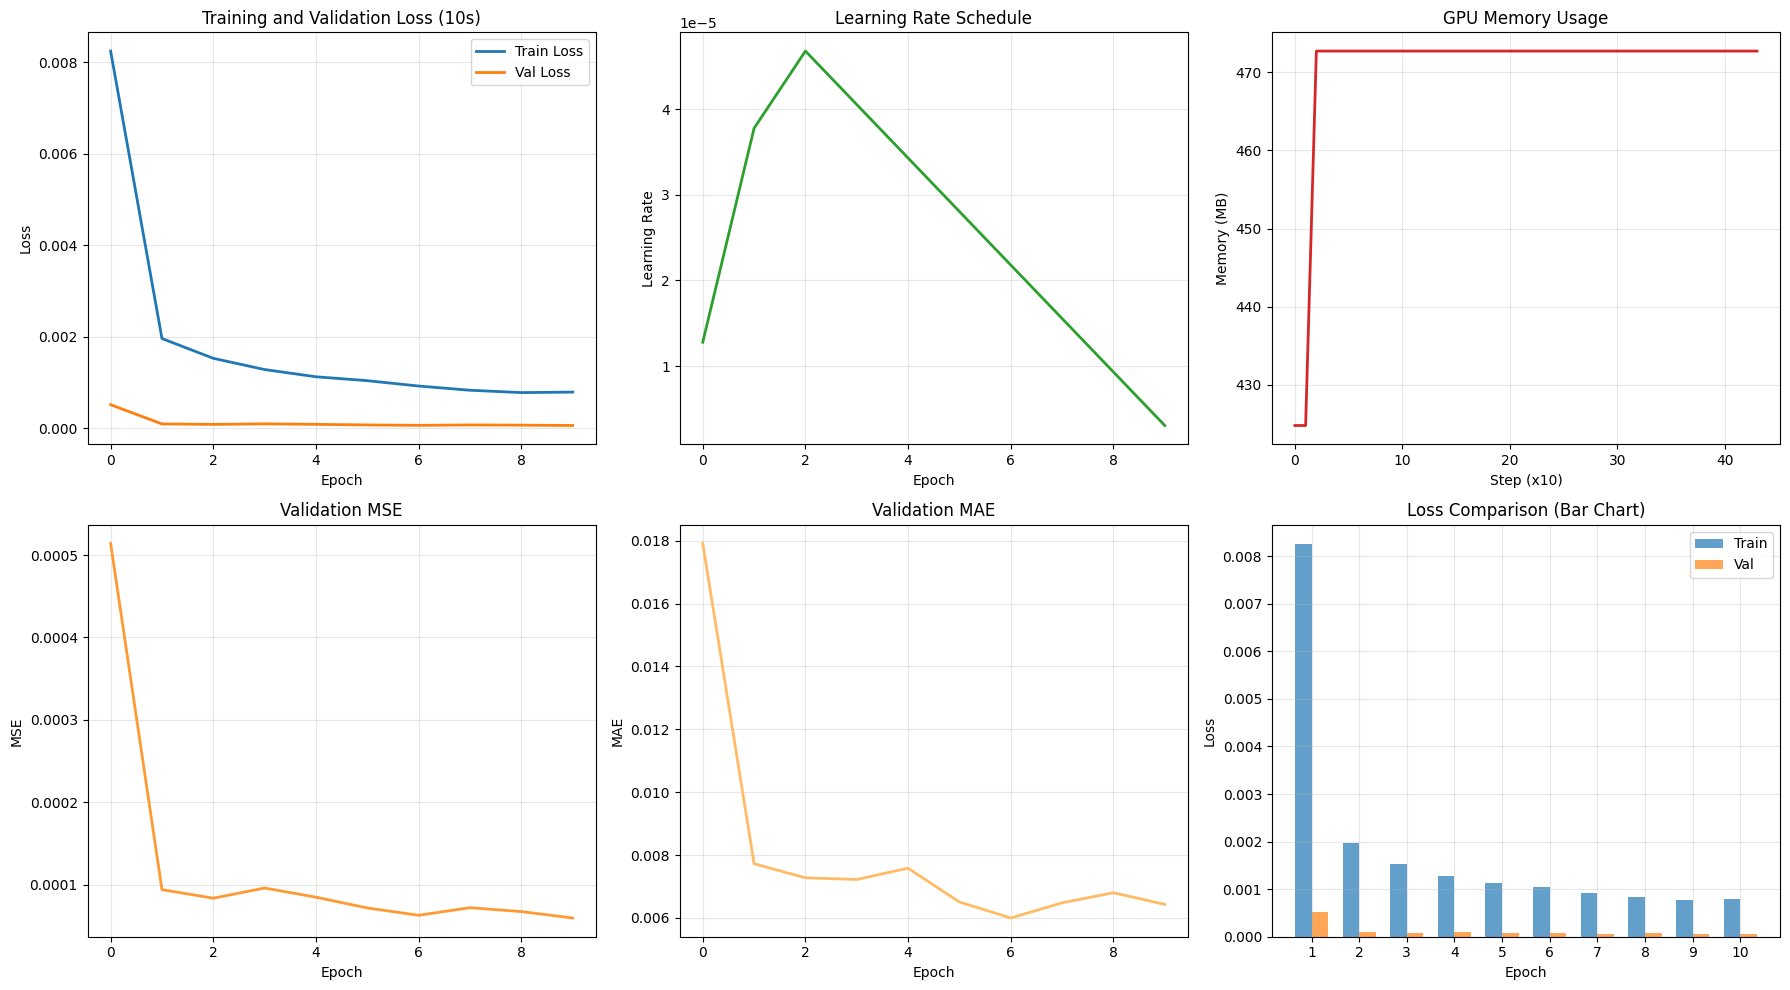

INFO:__main__:Training plot saved to ..\code\data\jupyter\llm\checkpoints\efficient_ft\10s\training_history_10s.png
INFO:__main__:Training summary saved to ..\code\data\jupyter\llm\checkpoints\efficient_ft\10s\training_summary.json
INFO:__main__:
INFO:__main__:COMPLETED TRAINING FOR 10s
INFO:__main__:Final Validation MAE: 0.0060
INFO:__main__:================================================================================
INFO:__main__:Successfully completed training for 10s
INFO:__main__:
Processing time interval: 30s
INFO:__main__:
INFO:__main__:TRAINING FOR TIME INTERVAL: 30s
INFO:__main__:================================================================================
INFO:__main__:Initializing model with pretrained weights...
INFO:__main__:Loading pretrained model from ../code/data/jupyter/llm/checkpoints/multi_dataset_pretrain/final_model.pt
INFO:__main__:Pretrained weights loaded successfully
INFO:__main__:Applying LoRA with rank=16, alpha=32
INFO:__main__:LoRA applied to 6 laye

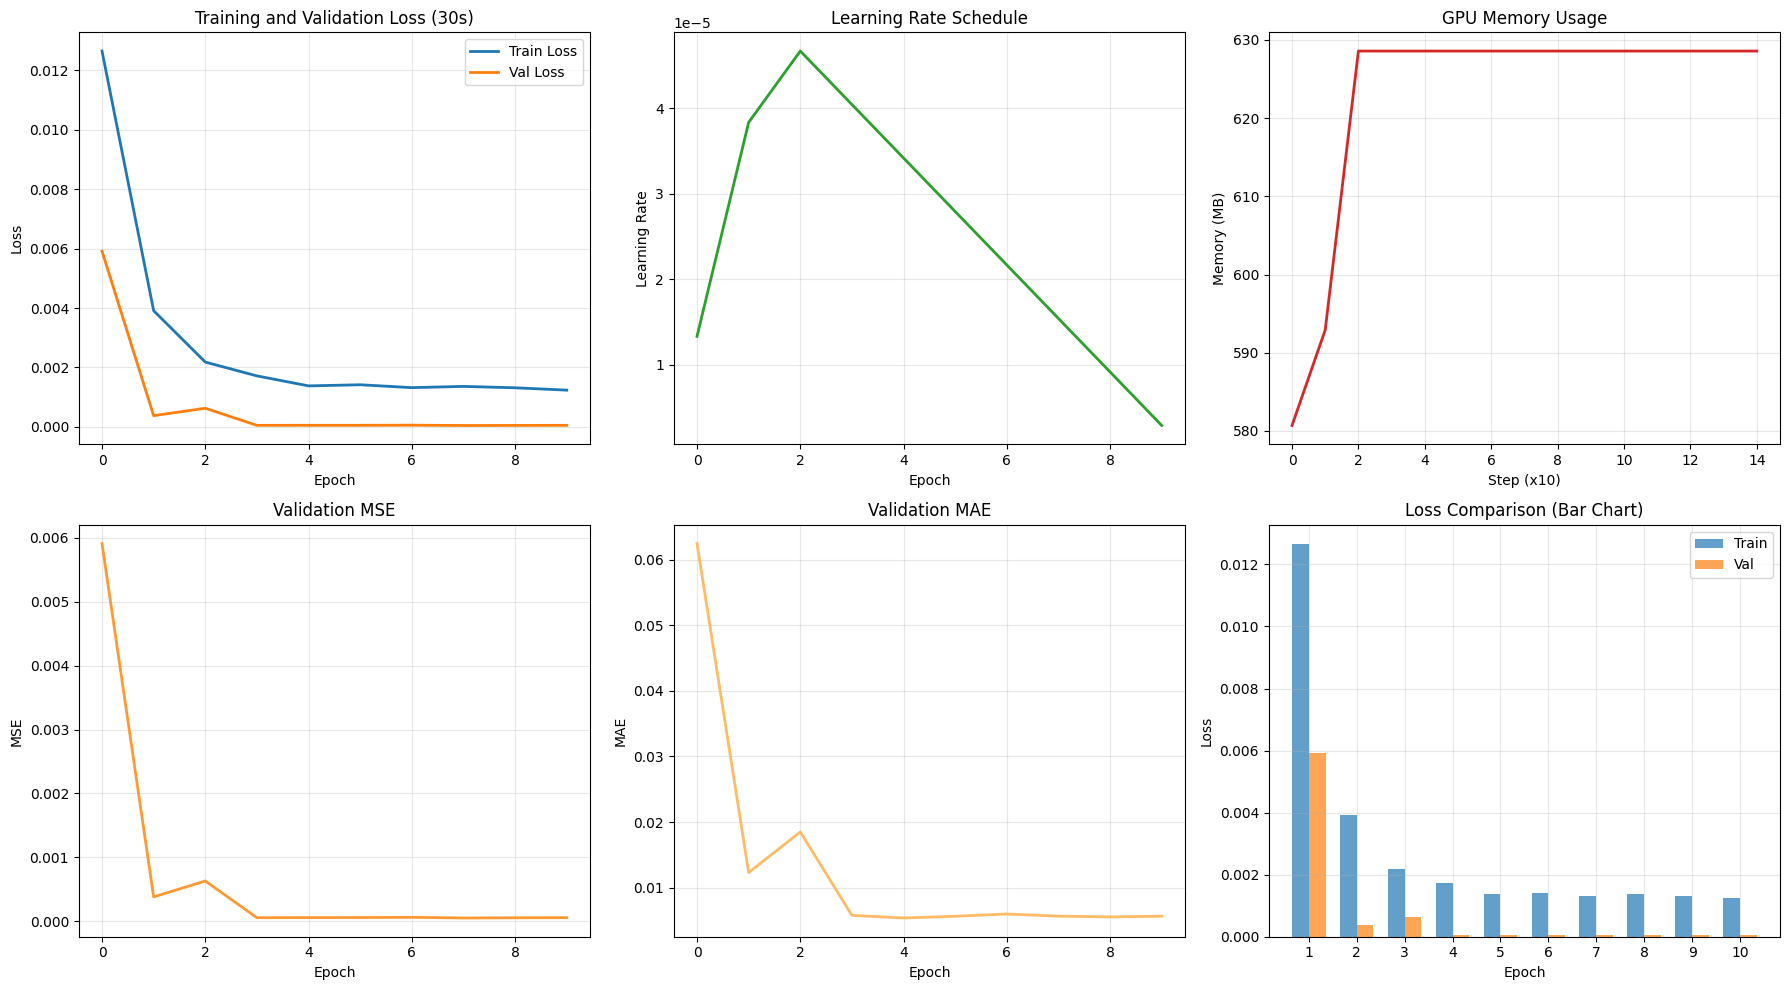

INFO:__main__:Training plot saved to ..\code\data\jupyter\llm\checkpoints\efficient_ft\30s\training_history_30s.png
INFO:__main__:Training summary saved to ..\code\data\jupyter\llm\checkpoints\efficient_ft\30s\training_summary.json
INFO:__main__:
INFO:__main__:COMPLETED TRAINING FOR 30s
INFO:__main__:Final Validation MAE: 0.0054
INFO:__main__:================================================================================
INFO:__main__:Successfully completed training for 30s
INFO:__main__:
Processing time interval: 1min
INFO:__main__:
INFO:__main__:TRAINING FOR TIME INTERVAL: 1min
INFO:__main__:================================================================================
INFO:__main__:Initializing model with pretrained weights...
INFO:__main__:Loading pretrained model from ../code/data/jupyter/llm/checkpoints/multi_dataset_pretrain/final_model.pt
INFO:__main__:Pretrained weights loaded successfully
INFO:__main__:Applying LoRA with rank=16, alpha=32
INFO:__main__:LoRA applied to 6 la

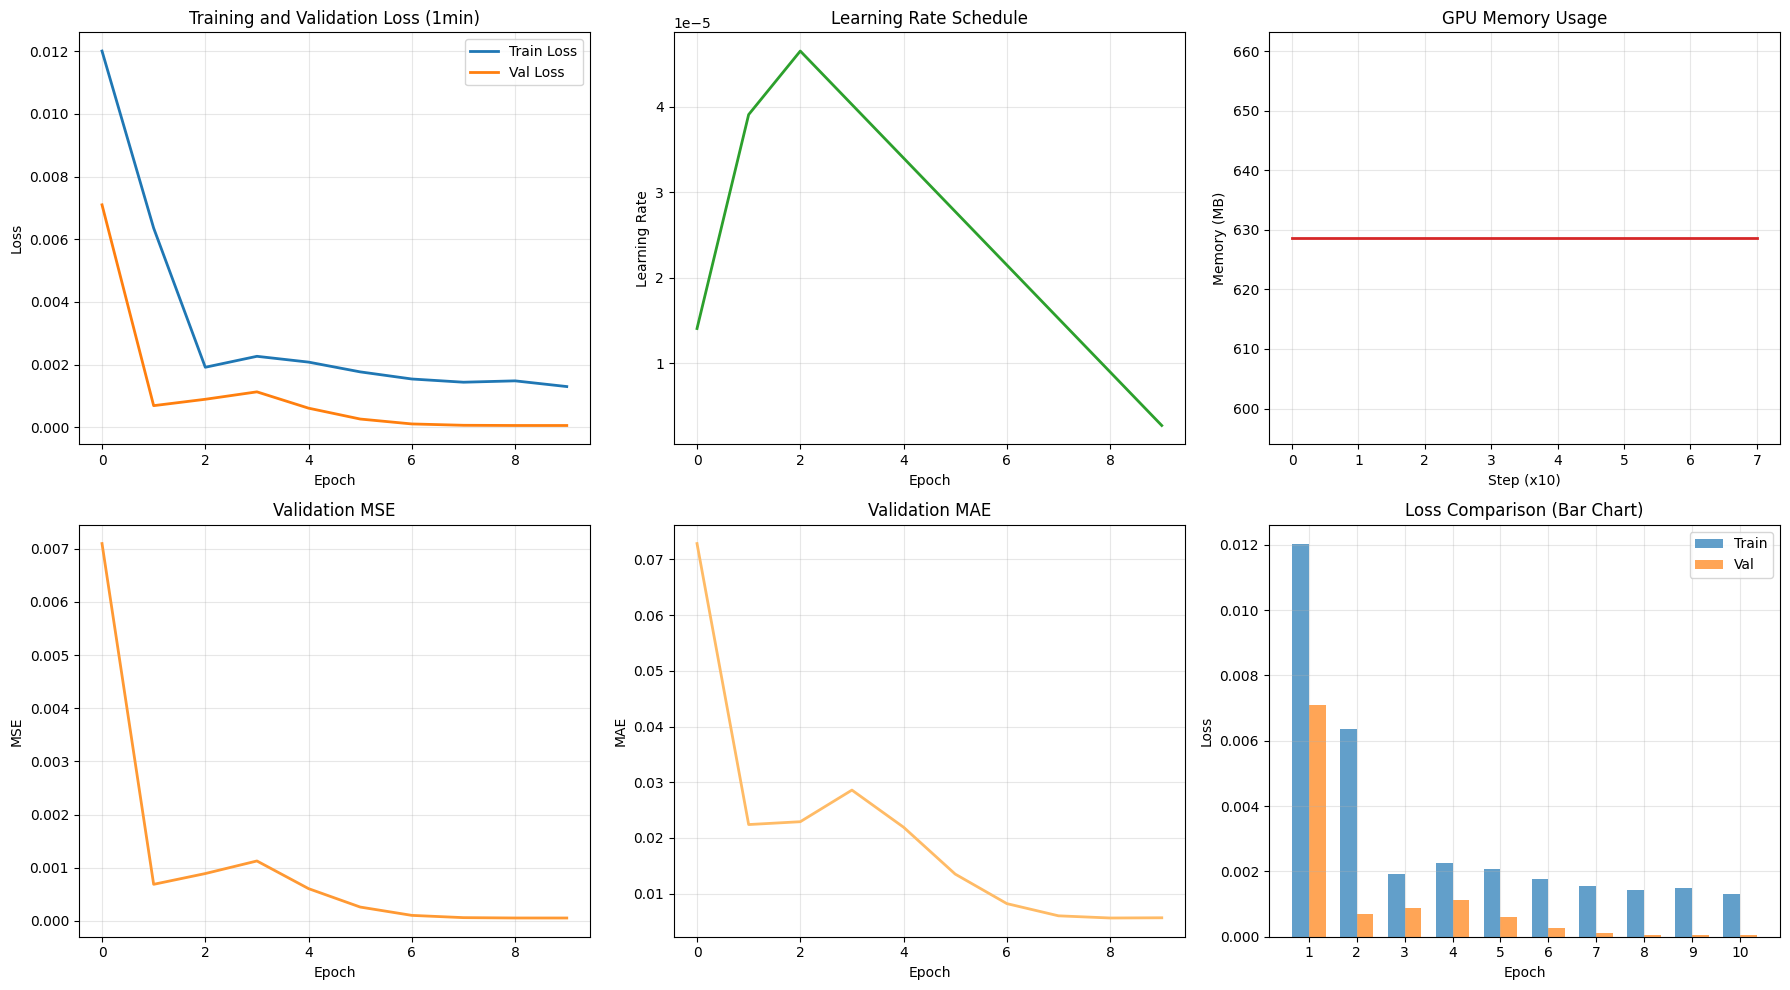

INFO:__main__:Training plot saved to ..\code\data\jupyter\llm\checkpoints\efficient_ft\1min\training_history_1min.png
INFO:__main__:Training summary saved to ..\code\data\jupyter\llm\checkpoints\efficient_ft\1min\training_summary.json
INFO:__main__:
INFO:__main__:COMPLETED TRAINING FOR 1min
INFO:__main__:Final Validation MAE: 0.0056
INFO:__main__:================================================================================
INFO:__main__:Successfully completed training for 1min
INFO:__main__:
INFO:__main__:COMPARATIVE ANALYSIS ACROSS TIME INTERVALS
INFO:__main__:================================================================================
INFO:__main__:
Comparative analysis saved to ..\code\data\jupyter\llm\checkpoints\efficient_ft\comparative_analysis.csv
INFO:__main__:Consolidated results saved to ..\code\data\jupyter\llm\checkpoints\efficient_ft\all_intervals_results.json
INFO:__main__:
INFO:__main__:training complete
INFO:__main__:Successful: ['10s', '30s', '1min']
INFO:__main


Comparative Results:
Time Interval  Train Samples  Val Samples Final Val Loss Best Val MAE Trainable Params LoRA Params
          10s            695          174         0.0001       0.0060        7,519,644     933,888
          30s            232           59         0.0001       0.0054        7,519,644     933,888
         1min            116           30         0.0001       0.0056        7,519,644     933,888


In [13]:
if __name__ == "__main__":
    results = main()